Google Collab: https://colab.research.google.com/drive/1LayfG3fim_TcBoOvDVNJM-Yp8usB_XsB?usp=sharing

Все запускал на VM в датасфере (иначе вообще не запускалось / было совсем плохо):

- CPU 28 ядер
- RAM 119 ГБ
- GPU 1x A100

Ник на каггле: DANILA_LYAPIN

In [1]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

from recbole.quick_start import load_data_and_model
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.general_recommender import BPR, LightGCN, MultiVAE
from recbole.trainer import Trainer
from recbole.utils import init_seed, init_logger

2025-06-04 09:01:54,939	INFO util.py:159 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-06-04 09:01:55,330	INFO util.py:159 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-06-04 09:01:55.850495: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-04 09:01:56.848732: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
train_df = pd.read_csv('hse_train.csv')
print(train_df.shape)
train_df.columns = ['user_id:token', 'item_id:token', 'timestamp:float']
train_df.to_csv('dataset/recbole_data/recbole_data.inter', sep='\t', index=False)
train_df.head()

(4842338, 3)


,user_id:token,item_id:token,timestamp:float
0,258671,74254,1511701649
1,258671,115615,1511841435
2,258671,176624,1512105022
3,240498,45484,1511605442
4,240498,39504,1511756830


In [ ]:
# общий конфиг
config = {
    'data_path': './',
    'USER_ID_FIELD': 'user_id',
    'ITEM_ID_FIELD': 'item_id',
    'TIME_FIELD': 'timestamp',
    'load_col': {'inter': ['user_id', 'item_id', 'timestamp']},
    'DATASET_NAME': 'recbole_data',
    'data_path': 'dataset/',
    'dataset': 'recbole_data',
    'data_file': 'recbole_data.inter',
    'eval_args': {
        'split': {'RS': [1.0, 0.0, 0.0]},
        'order': 'TO'
    },
    'metrics': ['Recall', 'NDCG'],
    'topk': [20],
    'train_batch_size': 8192,
    'eval_batch_size': 8192,
    'predict_batch_size': 8192,
    'num_workers': 24,
    'epochs': 20,
    # 'eval_step': 5,  #  каждую N итерацию проверяем валидационные метрики
    'valid_metric': 'NDCG@20',
    'seed': 42,
    'device': 'cuda',
    'verbose': True,
    'show_progress': True,
}


def train_model(model_name, model_class, config):    
    model_config = Config(config_dict=config)
    dataset = create_dataset(model_config)
    train_data, valid_data, test_data = data_preparation(model_config, dataset)
    
    model = model_class(model_config, train_data.dataset).to(model_config['device'])
    trainer = Trainer(model_config, model)
    metrics = trainer.fit(train_data, saved=False, show_progress=True)
    # print(f'{metrics=}')
    return model, dataset, train_data

def recommend_model(dataset, model_config, model, train_data):
    all_users = list(range(train_data.dataset.user_num))
    recommendations = {}
    batch_size = 8192
    for start in tqdm(range(0, len(all_users), batch_size)):
        end = min(start + batch_size, len(all_users))
        batch_users = all_users[start:end]

        for idx, user_idx in enumerate(batch_users):
            interaction = {}
            interaction[model_config['USER_ID_FIELD']] = torch.tensor([user_idx]).to(model_config['device'])
            scores = model.full_sort_predict(interaction)
            _, topk_indices = torch.topk(scores, k=20)
            topk_indices_list = topk_indices.squeeze().cpu().tolist()
            if not isinstance(topk_indices_list, list):
                topk_indices_list = [topk_indices_list]
            user_id = dataset.id2token(model_config['USER_ID_FIELD'], user_idx)
            item_ids = [dataset.id2token(model_config['ITEM_ID_FIELD'], item_idx) for item_idx in topk_indices_list]
            recommendations[user_id] = item_ids
    
    return recommendations

In [4]:
torch.cuda.empty_cache()

### BPR model

In [ ]:
init_seed(config['seed'], reproducibility=True)

bpr_config = config.copy()

#                                   первая итерация:
# bpr_config.update({
#     'embedding_size': 64,
#     'learning_rate': 0.01,
#     'model': 'BPR',
# })

#                                   вторая итерация:
# bpr_config.update({
#     'embedding_size': 128,
#     'learning_rate': 0.005,
#     'model': 'BPR',
#     'learner': 'Adam',
#     'epochs': 50,
#     'stopping_step': 5,
#     'scheduler': 'plateau',
#     'reduce_lr_on_plateau': 'patience=3,factor=0.5',
#     'train_neg_sample_args': {
#         'distribution': 'uniform',
#         'sample_num': 5,
#         'dynamic_theta': 0.5,
#     },
# })

#                                   третья итерация (больше эпох):
bpr_config.update({
    'embedding_size': 128,
    'learning_rate': 0.005,
    'model': 'BPR',
    'learner': 'Adam',
    'epochs': 100,
    'stopping_step': 5,
    'scheduler': 'plateau',
    'reduce_lr_on_plateau': 'patience=3,factor=0.5',
    'train_neg_sample_args': {
        'distribution': 'uniform',
        'sample_num': 5,
        'dynamic_theta': 0.5,
    },
})


bpr_model, dataset, train_data = train_model('BPR', BPR, bpr_config)

command line args [--shell 12501 --control 12504 --stdin 12503 --hb 12500 --iopub 12502 --debug -f /dev/shm/kernel-connection-file.json] will not be used in RecBole
Train    99: 100%|████████████████████| 2957/2957 [00:21<00:00, 136.35it/s, GPU RAM: 2.16 G/79.33 G]

metrics=(-inf, None)


In [7]:
bpr_recs = recommend_model(dataset, bpr_config, bpr_model, train_data)

100%|██████████| 86/86 [03:27<00:00,  2.41s/it]


In [8]:
bpr_rec_df = pd.DataFrame([(user, ', '.join(map(str, items))) for user, items in bpr_recs.items()],
                         columns=['user_id', f'bpr_recommendations'])
bpr_rec_df = bpr_rec_df.iloc[1:]  # убрал PAD
bpr_rec_df['bpr_recommendations'] = bpr_rec_df['bpr_recommendations'].str.split(', ')
bpr_rec_df = bpr_rec_df.explode('bpr_recommendations').rename(columns={'bpr_recommendations': 'items'})

In [9]:
bpr_rec_df.to_csv('bpr_model_100epochs_sub.csv', index=False)

`100 эпох показали лучший результат на каггле: NDCG@20 = 0.047`

### LightGCN model

In [ ]:
lightgcn_config = config.copy()

#                                   первая итерация:
# lightgcn_config.update({
#     'embedding_size': 128,
#     'n_layers': 3,
#     'learning_rate': 0.005,
#     'model': 'LightGCN',
#     'reg_weight': 1e-5,
#     'epochs': 50,
#     'eval_step': 0,
#     'learner': 'Adam',
#     'stopping_step': 5,
#     'scheduler': 'plateau',
#     'reduce_lr_on_plateau': 'patience=3,factor=0.5', # в 2 раза снижаем после 3 эпох без улучшений
#     'train_neg_sample_args': {
#         'distribution': 'popularity',
#         'sample_num': 3,
#         'alpha': 0.75,
#     },
#     'train_batch_size': 131072,
#     'eval_batch_size': 131072,
# })

#                                   вторая итерация:
lightgcn_config.update({
    'embedding_size': 128,
    'n_layers': 3,
    'learning_rate': 0.005,
    'model': 'LightGCN',
    'reg_weight': 1e-5,
    'epochs': 60,
    'eval_step': 0,
    'learner': 'Adam',
    'stopping_step': 5,
    'scheduler': 'plateau',
    'reduce_lr_on_plateau': 'patience=3,factor=0.5',
    'train_neg_sample_args': {
        'distribution': 'popularity',
        'sample_num': 3,
        'alpha': 0.75,
    },
    'train_batch_size': 131072,
    'eval_batch_size': 131072,
})

lightgcn_config = Config(config_dict=lightgcn_config)
dataset = create_dataset(lightgcn_config)
train_data, valid_data, test_data = data_preparation(lightgcn_config, dataset)

command line args [--shell 12501 --control 12504 --stdin 12503 --hb 12500 --iopub 12502 --debug -f /dev/shm/kernel-connection-file.json] will not be used in RecBole


In [ ]:
lightgcn_model = LightGCN(lightgcn_config, train_data.dataset).to(lightgcn_config['device'])
trainer = Trainer(lightgcn_config, lightgcn_model)
metrics = trainer.fit(train_data, saved=False, show_progress=True)

Train    59: 100%|██████████████████████| 111/111 [00:41<00:00,  2.65it/s, GPU RAM: 14.98 G/79.33 G]


In [ ]:
lightgcn_recs = recommend_model(dataset, lightgcn_config, lightgcn_model, train_data)

100%|██████████| 86/86 [03:29<00:00,  2.43s/it]


In [ ]:
lightgcn_recs_df = pd.DataFrame([(user, ', '.join(map(str, items))) for user, items in lightgcn_recs.items()],
                         columns=['user_id', f'lightgcn_recommendations'])
lightgcn_recs_df = lightgcn_recs_df.iloc[1:]  # убрал PAD
lightgcn_recs_df['lightgcn_recommendations'] = lightgcn_recs_df['lightgcn_recommendations'].str.split(', ')
lightgcn_recs_df = lightgcn_recs_df.explode('lightgcn_recommendations').rename(columns={'lightgcn_recommendations': 'items'})

In [ ]:
lightgcn_recs_df.to_csv('lightgcn_recs_60epochs.csv', index=False)  # побил бейзлайн3, походу сегодня напьюсь...

In [ ]:
torch.cuda.empty_cache()

### MultiVAE model

In [ ]:
multivae_config = config.copy()
#                                   первая итерация:
# multivae_config.update({
#     'model': 'MultiVAE',
#     'latent_dimension': 128,
#     'dropout_prob': 0.1,
#     'beta': 0.2,
#     'weight_decay': 0.00001, 
#     'anneal_cap': 0.3,
#     'total_anneal_steps': 200000,
#     'learning_rate': 0.001,
#     'train_batch_size': 16384,
#     'eval_batch_size': 16384,
#     'predict_batch_size': 16384,
#     'epochs': 100,
#     'stopping_step': 5,
#     'early_stopping': True,
#     'train_neg_sample_args': {
#         'distribution': 'popularity',
#         'sample_num': 3,
#         'alpha': 0.75,
#     },
# })

#                                   вторая итерация:
multivae_config.update({
    'model': 'MultiVAE',
    'latent_dimension': 200,
    'mlp_hidden_size': [600],
    'encoder_hidden_size': [600, 300],
    'decoder_hidden_size': [600],
    
    
    'dropout_prob': 0.2,
    'beta': 0.15,
    'weight_decay': 0.00001, 
    'anneal_cap': 0.3,
    'total_anneal_steps': 200000,
    'learning_rate': 0.002,
    'train_batch_size': 16384,
    'eval_batch_size': 16384,
    'predict_batch_size': 16384,

    'epochs': 100,
    'stopping_step': 5,
    'early_stopping': True,
    
    'train_neg_sample_args': {
        'distribution': 'popularity',
        'sample_num': 3,
        'alpha': 0.75,
    },
})

multivae_config = Config(config_dict=multivae_config)
dataset = create_dataset(multivae_config)
train_data, valid_data, test_data = data_preparation(multivae_config, dataset)

command line args [--shell 12501 --control 12504 --stdin 12503 --hb 12500 --iopub 12502 --debug -f /dev/shm/kernel-connection-file.json] will not be used in RecBole


In [7]:
torch.cuda.empty_cache()

In [ ]:
multivae_model = MultiVAE(multivae_config, train_data.dataset).to(multivae_config['device'])
trainer = Trainer(multivae_config, multivae_model)
metrics = trainer.fit(train_data, saved=False, show_progress=True)

Train    92:  98%|███████████████████████▍| 42/43 [00:49<00:01,  1.19s/it, GPU RAM: 60.59 G/79.33 G]

In [9]:
multivae_recs = recommend_model(dataset, multivae_config, multivae_model, train_data)

100%|██████████| 86/86 [12:11<00:00,  8.50s/it]


In [10]:
multivae_recs_df = pd.DataFrame([(user, ', '.join(map(str, items))) for user, items in multivae_recs.items()],
                         columns=['user_id', f'multivae_recommendations'])
multivae_recs_df = multivae_recs_df.iloc[1:]  # убрал PAD
multivae_recs_df['multivae_recommendations'] = multivae_recs_df['multivae_recommendations'].str.split(', ')
multivae_recs_df = multivae_recs_df.explode('multivae_recommendations').rename(columns={'multivae_recommendations': 'items'})

In [11]:
multivae_recs_df.to_csv('multivae_recs_100epochs_v2.csv', index=False)

### **Итоговая сравнительная таблица моделей:**

Мной были рассмотрены и более простые модели в качестве бейзлайна, но они давали крайне плохой результат, поэтому даже не вставил в этот блокнотик.

| Модель             | Основные параметры | NDCG@20 на каггле|
|--------------------|-----------|------------------|
| TopPopular         |          | 0.002           |
| implicitKNN        | K=25      | 0.006           |
| iALS        | factors=32, iterations=15, regularization=0.05      | 0.002           |
| BPR | embedding_size=64, epochs=20 | 0.022 |
| BPR | embedding_size=128, epochs=50 | 0.046 |
| BPR | embedding_size=128, epochs=120 | 0.047 |
| LightGCN | epochs=50 | 0.054 |
| LightGCN | epochs=60 | 0.056 |
| LightGCN | epochs=100 | 0.026 |
| MultiVAE | latent_dimension=128, epochs=100 | 0.054 |
| MultiVAE | latent_dimension=200, epochs=100 | 0.051 |
| SASRec |  | так и не удалось завести, хотя долго пытался (обучается быстро, а вот рекомендации очень долго делает)|


По итогам победила модель LightGCN, второе место - MultiVAE. Обе смогли побить бейзлайн3 (самый жесткий).
Эти сабмишны отметил как лучшие на каггле.

Возможно, для лучшего качества стоило построить ансамбли на этих моделях, но деньги на датасфере не бесконечные :/

![Снимок экрана 2025-06-04 в 13.40.20.png](<attachment:Снимок экрана 2025-06-04 в 13.40.20.png>)
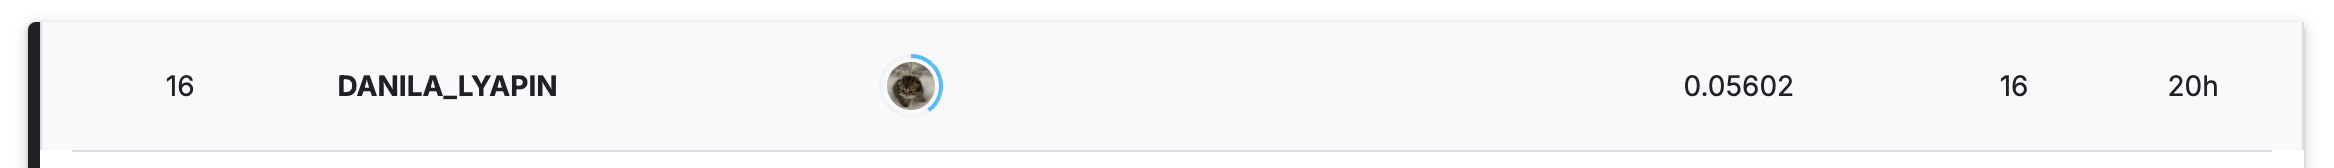